# House Price Prediction – Model Comparison (California Housing)

This notebook benchmarks **three regression approaches** on the California Housing dataset:

| # | Model | Implementation |
|---|-------|---------------|
| 1 | **Linear Regression** | From Scratch (Gradient Descent) |
| 2 | **SVR** (Support Vector Regression) | From Scratch (Subgradient Descent, ε-insensitive loss) |
| 3 | **PyTorch MLP** | Multilayer Perceptron |

Models are compared across **three feature scenarios**: Full Features (23) · PCA (95% variance) · Mutual Information Top-10.

**Target preprocessing**: `StandardScaler` only — no log transform.

**Hyperparameter Optimization**: Tuned using **Optuna** (Bayesian Optimization) instead of Grid Search to efficiently find optimal learning rates, batch sizes, epochs, regularization, and SVR margin parameters.

In [1]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
# Added by Antigravity to support Optuna tuning
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\Win 11\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Data & Preprocess Target

In [2]:
X_train_df = pd.read_csv('../data/ready_train/X_train.csv')
X_test_df  = pd.read_csv('../data/ready_train/X_test.csv')
y_train_df = pd.read_csv('../data/ready_train/y_train.csv')
y_test_df  = pd.read_csv('../data/ready_train/y_test.csv')

X_train_full = X_train_df.values
X_test_full  = X_test_df.values
y_train = y_train_df.values  # shape (n, 1)
y_test  = y_test_df.values

# Scale target only (no log)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

print(f'X_train: {X_train_full.shape} | X_test: {X_test_full.shape}')
print(f'y mean={y_train.mean():.0f}  std={y_train.std():.0f}')

X_train: (16512, 22) | X_test: (4128, 22)
y mean=207195  std=115619


## 2. Feature Scenarios (PCA & Mutual-Info)

In [3]:
# PCA – retain 95 % variance
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train_full)
X_test_pca  = pca.transform(X_test_full)
print(f'PCA: {X_train_pca.shape[1]} components')

# Mutual Information – top 10
mi_scores = mutual_info_regression(X_train_full, y_train_sc.squeeze(), random_state=42)
top10_idx = np.argsort(mi_scores)[-10:]
X_train_mi = X_train_full[:, top10_idx]
X_test_mi  = X_test_full[:, top10_idx]
print(f'MI Top-10 feature indices: {top10_idx}')

SCENARIOS = [
    ('Full Features', X_train_full, X_test_full),
    ('PCA Features',  X_train_pca,  X_test_pca),
    ('MI Top-10',     X_train_mi,   X_test_mi),
]

PCA: 9 components


MI Top-10 feature indices: [20 18 13 19 14  1 21 12  7  0]


## 3. Model Definitions

In [4]:
# ─── Linear Regression (Scratch) ────────────────────────
class LinearRegressionScratch:
    def __init__(self, lr=0.001, epochs=1000):
        self.lr = lr; self.epochs = epochs
        self.w = self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros((d, 1)); self.b = 0.0; self.loss_hist = []
        for _ in range(self.epochs):
            yp = X @ self.w + self.b
            err = yp - y
            self.loss_hist.append(float(np.mean(err**2)))
            self.w -= self.lr * (2/n) * (X.T @ err)
            self.b -= self.lr * (2/n) * float(np.sum(err))

    def predict(self, X):
        return X @ self.w + self.b


# ─── SVR (Scratch) ───────────────────────────────────────
class SVRScratch:
    def __init__(self, lr=0.005, epochs=1000, C=1.0, epsilon=0.1, reg=0.1):
        self.lr=lr; self.epochs=epochs; self.C=C
        self.epsilon=epsilon; self.reg=reg
        self.w = self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros((d, 1)); self.b = 0.0; self.loss_hist = []
        for _ in range(self.epochs):
            yp  = X @ self.w + self.b
            err = y - yp
            loss = 0.5*self.reg*np.sum(self.w**2) + self.C*np.mean(np.maximum(0, np.abs(err)-self.epsilon))
            self.loss_hist.append(float(loss))
            mp = (err >  self.epsilon).squeeze()
            mn = (err < -self.epsilon).squeeze()
            gW = np.zeros_like(X)
            gW[mp] = -X[mp]; gW[mn] = X[mn]
            gW = np.mean(gW, axis=0, keepdims=True).T
            gb = np.zeros(n)
            gb[mp] = -1.0; gb[mn] = 1.0
            self.w -= self.lr*(self.reg*self.w + self.C*gW)
            self.b -= self.lr*self.C*np.mean(gb)

    def predict(self, X):
        return X @ self.w + self.b


# ─── PyTorch MLP ─────────────────────────────────────────
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_val, y_val, epochs=60, batch=256, lr=0.005, wd=0.001):
    ds = HouseDataset(X_tr, y_tr)
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    model = MLPRegressor(X_tr.shape[1])
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit  = nn.MSELoss()
    
    Xv = torch.tensor(X_val, dtype=torch.float32)
    yv = torch.tensor(y_val, dtype=torch.float32)
    
    tr_hist, val_hist, r2_hist = [], [], []
    
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for bX, by in loader:
            opt.zero_grad()
            l = crit(model(bX), by)
            l.backward()
            opt.step()
            ep_loss += l.item() * len(bX)
            
        train_loss = ep_loss / len(X_tr)
        tr_hist.append(train_loss)
        
        # Validation tại mỗi Epoch
        model.eval()
        with torch.no_grad():
            val_preds_scaled = model(Xv)
            vl = crit(val_preds_scaled, yv).item()
            val_hist.append(vl)
            
            # Tính R2 score của Epoch này
            preds_orig = inv(val_preds_scaled.numpy())
            y_val_orig = inv(yv.numpy())
            val_r2 = r2_score(y_val_orig, preds_orig)
            r2_hist.append(val_r2)
            
        sched.step(vl)
        
        # Dòng in ra kết quả như ảnh của bạn (In ra mỗi epoch hoặc mỗi 10 epochs tùy ý)
        # Ở đây in ra mỗi epoch:
        print(f'Epoch [{ep+1}/{epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {vl:.4f}, Validation R²: {val_r2:.2f}')
        
    return model, tr_hist, val_hist, r2_hist

print('Model classes defined.')

Model classes defined.


In [5]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

def inv(arr):
    """Inverse-transform scaled predictions back to USD."""
    return scaler_y.inverse_transform(arr.reshape(-1,1))

print('Helper functions ready.')

Helper functions ready.


## 4. Hyperparameter Tuning using Optuna

We use Optuna to optimize hyperparameters for each model. This is faster and explores parameter spaces more effectively than Grid Search.

In [6]:
# ── Tune Linear Regression with Optuna ─────────────────────
print('Tuning Linear Regression using Optuna...')
def lr_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    # Swap 500, 100 to 100, 500 so low <= high holds in Optuna
    epochs = trial.suggest_int('epochs', 100, 500)
    
    m = LinearRegressionScratch(lr=lr, epochs=epochs)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=10)
best_lr_params = lr_study.best_params
print(f'  Best LR params: {best_lr_params} | Best R2: {lr_study.best_value:.4f}')

# Display Top Trials
print(lr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'value']].head(5).to_string(index=False))


Tuning Linear Regression using Optuna...


  Best LR params: {'lr': 0.07774021601437332, 'epochs': 466} | Best R2: 0.6132
 params_lr  params_epochs    value
  0.077740            466 0.613178
  0.002226            422 0.604142
  0.046159            478 0.603166
  0.087906            199 0.597831
  0.002679            201 0.588582


In [7]:
# ── Tune SVR Scratch with Optuna ──────────────────────────
print('Tuning SVR Scratch using Optuna...')
def svr_objective(trial):
    # Use suggest_categorical to select from a specific list of discrete values
    lr = trial.suggest_categorical('lr', [0.001, 0.005, 0.01, 0.05])
    epochs = trial.suggest_int('epochs', 500, 1000)
    C = trial.suggest_categorical('C', [0.001, 0.01, 0.1, 5.0])
    epsilon = trial.suggest_float('epsilon', 0.01, 0.3)
    reg = trial.suggest_float('reg', 0.01, 0.5)
    
    m = SVRScratch(lr=lr, epochs=epochs, C=C, epsilon=epsilon, reg=reg)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

svr_study = optuna.create_study(direction='maximize')
svr_study.optimize(svr_objective, n_trials=10)
best_svr_params = svr_study.best_params
print(f'  Best SVR params: {best_svr_params} | Best R2: {svr_study.best_value:.4f}')

# Display Top Trials
print(svr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'params_C', 'params_epsilon', 'params_reg', 'value']].head(5).to_string(index=False))


Tuning SVR Scratch using Optuna...


  Best SVR params: {'lr': 0.01, 'epochs': 616, 'C': 5.0, 'epsilon': 0.05471145455231211, 'reg': 0.012168981750313442} | Best R2: 0.5928
 params_lr  params_epochs  params_C  params_epsilon  params_reg    value
     0.010            616       5.0        0.054711    0.012169 0.592776
     0.010            500       5.0        0.014731    0.278705 0.586060
     0.010            883       0.1        0.019079    0.185963 0.460549
     0.005            802       0.1        0.228362    0.197031 0.392280
     0.005            795       0.1        0.221884    0.321618 0.344042


In [8]:
# ── Tune PyTorch MLP with Optuna ──────────────────────────
print('Tuning PyTorch MLP using Optuna...')
def mlp_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch', [64, 128, 256])
    wd = trial.suggest_float('wd', 1e-5, 1e-2, log=True)
    
    # Use a fixed 30 epochs for fast optimization trial runs
    m, _, _, _= train_mlp(X_train_full, y_train_sc, X_test_full, y_test_sc,
                        epochs=20, batch=batch, lr=lr, wd=wd)
    m.eval()
    with torch.no_grad():
        p = inv(m(torch.tensor(X_test_full, dtype=torch.float32)).numpy())
    return r2_score(y_test, p)

mlp_study = optuna.create_study(direction='maximize')
mlp_study.optimize(mlp_objective, n_trials=10)
best_mlp_params = mlp_study.best_params.copy()
# Add standard 60 epochs for final scenario run
best_mlp_params['epochs'] = 100
print(f'  Best MLP params (for final training): {best_mlp_params} | Best R2: {mlp_study.best_value:.4f}')

# Display Top Trials
print(mlp_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_batch', 'params_wd', 'value']].head(5).to_string(index=False))

Tuning PyTorch MLP using Optuna...


Epoch [1/20], Train Loss: 0.3282, Validation Loss: 0.2800, Validation R²: 0.71


Epoch [2/20], Train Loss: 0.2837, Validation Loss: 0.2619, Validation R²: 0.73


Epoch [3/20], Train Loss: 0.2763, Validation Loss: 0.2638, Validation R²: 0.73


Epoch [4/20], Train Loss: 0.2700, Validation Loss: 0.2986, Validation R²: 0.70


...

Epoch [16/20], Train Loss: 0.2431, Validation Loss: 0.2368, Validation R²: 0.76


Epoch [17/20], Train Loss: 0.2425, Validation Loss: 0.2365, Validation R²: 0.76


Epoch [18/20], Train Loss: 0.2402, Validation Loss: 0.2500, Validation R²: 0.74


Epoch [19/20], Train Loss: 0.2378, Validation Loss: 0.2354, Validation R²: 0.76


Epoch [20/20], Train Loss: 0.2383, Validation Loss: 0.2318, Validation R²: 0.76
  Best MLP params (for final training): {'lr': 0.0013274885393510616, 'batch': 128, 'wd': 3.553340745911598e-05, 'epochs': 100} | Best R2: 0.7822
 params_lr  params_batch  params_wd    value
  0.001327           128   0.000036 0.782209
  0.000495            64   0.000025 0.777640
  0.002030           128   0.000052 0.776240
  0.003232            64   0.000054 0.769831
  0.002389            64   0.000207 0.768836


## 5. Full Experiment: All Models × All Scenarios

Using tuned hyperparameters, train each model on every feature scenario and collect metrics + loss histories.

In [9]:
results   = []
loss_store = {}  # key: (scenario, model_name) -> (train_hist, val_hist or None)
pred_store = {}  # key: (scenario, model_name) -> y_pred (original USD scale)

for sc_name, X_tr, X_ts in SCENARIOS:
    print(f'\n=== Scenario: {sc_name} ===')

    # ── 1. Linear Regression ──────────────────────────────
    t0 = time.time()
    lr_m = LinearRegressionScratch(**best_lr_params)
    lr_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    lr_pred = inv(lr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, lr_pred)
    results.append({'Scenario': sc_name, 'Model': 'LR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'LR Scratch')] = (lr_m.loss_hist, None)
    pred_store[(sc_name, 'LR Scratch')] = lr_pred
    print(f'  LR  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 2. SVR Scratch ────────────────────────────────────
    t0 = time.time()
    svr_m = SVRScratch(**best_svr_params)
    svr_m.fit(X_tr, y_train_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    svr_pred = inv(svr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, svr_pred)
    results.append({'Scenario': sc_name, 'Model': 'SVR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'SVR Scratch')] = (svr_m.loss_hist, None)
    pred_store[(sc_name, 'SVR Scratch')] = svr_pred
    print(f'  SVR R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 3. PyTorch MLP ───────────────────────────────────
    t0 = time.time()
    mlp_m, tr_hist, val_hist, r2_hist = train_mlp(
        X_tr, y_train_sc, X_ts, y_test_sc,
        **best_mlp_params)
    train_ms = (time.time()-t0)*1000
    mlp_m.eval()
    t0 = time.time()
    with torch.no_grad():
        mlp_pred = inv(mlp_m(torch.tensor(X_ts, dtype=torch.float32)).numpy())
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_test, mlp_pred)
    results.append({'Scenario': sc_name, 'Model': 'MLP',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_name, 'MLP')] = (tr_hist, val_hist)
    pred_store[(sc_name, 'MLP')] = mlp_pred
    print(f'  MLP R2={r2:.4f}  MAPE={mape:.2f}%')

df = pd.DataFrame(results)
print('\n--- Summary Table ---')
print(df[['Scenario','Model','MAE','RMSE','MAPE(%)','R2']].to_string(index=False))


=== Scenario: Full Features ===


  LR  R2=0.6132  MAPE=29.98%


  SVR R2=0.5928  MAPE=28.05%


Epoch [1/100], Train Loss: 0.3515, Validation Loss: 0.3140, Validation R²: 0.68


Epoch [2/100], Train Loss: 0.2768, Validation Loss: 0.2728, Validation R²: 0.72


...

Epoch [96/100], Train Loss: 0.2215, Validation Loss: 0.2312, Validation R²: 0.76


Epoch [97/100], Train Loss: 0.2199, Validation Loss: 0.3463, Validation R²: 0.65


Epoch [98/100], Train Loss: 0.2184, Validation Loss: 0.3098, Validation R²: 0.68


Epoch [99/100], Train Loss: 0.2185, Validation Loss: 0.2373, Validation R²: 0.76


Epoch [100/100], Train Loss: 0.2202, Validation Loss: 0.2209, Validation R²: 0.77
  MLP R2=0.7747  MAPE=20.51%

--- Summary Table ---
     Scenario       Model          MAE         RMSE   MAPE(%)       R2
Full Features  LR Scratch 50165.738674 71196.516660 29.984057 0.613178
Full Features SVR Scratch 49675.856516 73049.961381 28.048252 0.592776
Full Features         MLP 34408.328125 52315.246267 19.142729 0.791143
 PCA Features  LR Scratch 55462.135298 80185.721110 33.169300 0.509333
 PCA Features SVR Scratch 53091.184901 79615.251635 30.171004 0.516289
 PCA Features         MLP 44479.542969 67638.409916 22.387450 0.650876
    MI Top-10  LR Scratch 53958.934819 77447.018021 30.920068 0.542277
    MI Top-10 SVR Scratch 51670.272007 77551.869316 27.685939 0.541037
    MI Top-10         MLP 36038.597656 54337.948139 20.512103 0.774680


## 6. Learning Curves (Best Scenario: Full Features)

Loss curves show convergence behaviour on the Full-Feature scenario for all three models.

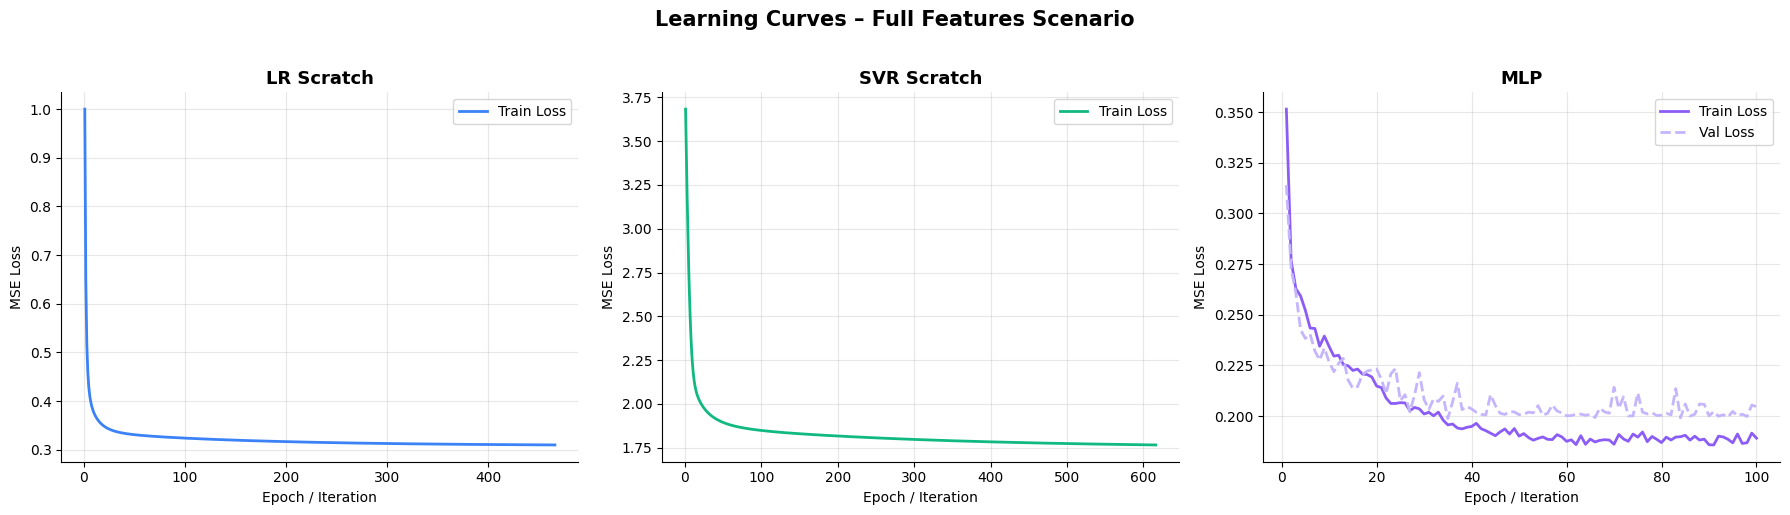

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Learning Curves – Full Features Scenario', fontsize=15, fontweight='bold', y=1.02)

model_names = ['LR Scratch', 'SVR Scratch', 'MLP']
colors = [('#3B82F6', '#93C5FD'), ('#10B981', '#6EE7B7'), ('#8B5CF6', '#C4B5FD')]

for ax, mname, (c_tr, c_val) in zip(axes, model_names, colors):
    tr_hist, val_hist = loss_store[('Full Features', mname)]
    epochs_x = range(1, len(tr_hist)+1)
    ax.plot(epochs_x, tr_hist, color=c_tr, lw=2, label='Train Loss')
    if val_hist:
        ax.plot(epochs_x, val_hist, color=c_val, lw=2, linestyle='--', label='Val Loss')
    ax.set_title(f'{mname}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch / Iteration')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Metrics Comparison – Visualisation

Bar charts comparing MAE, RMSE, MAPE, and R² across all three models and scenarios.

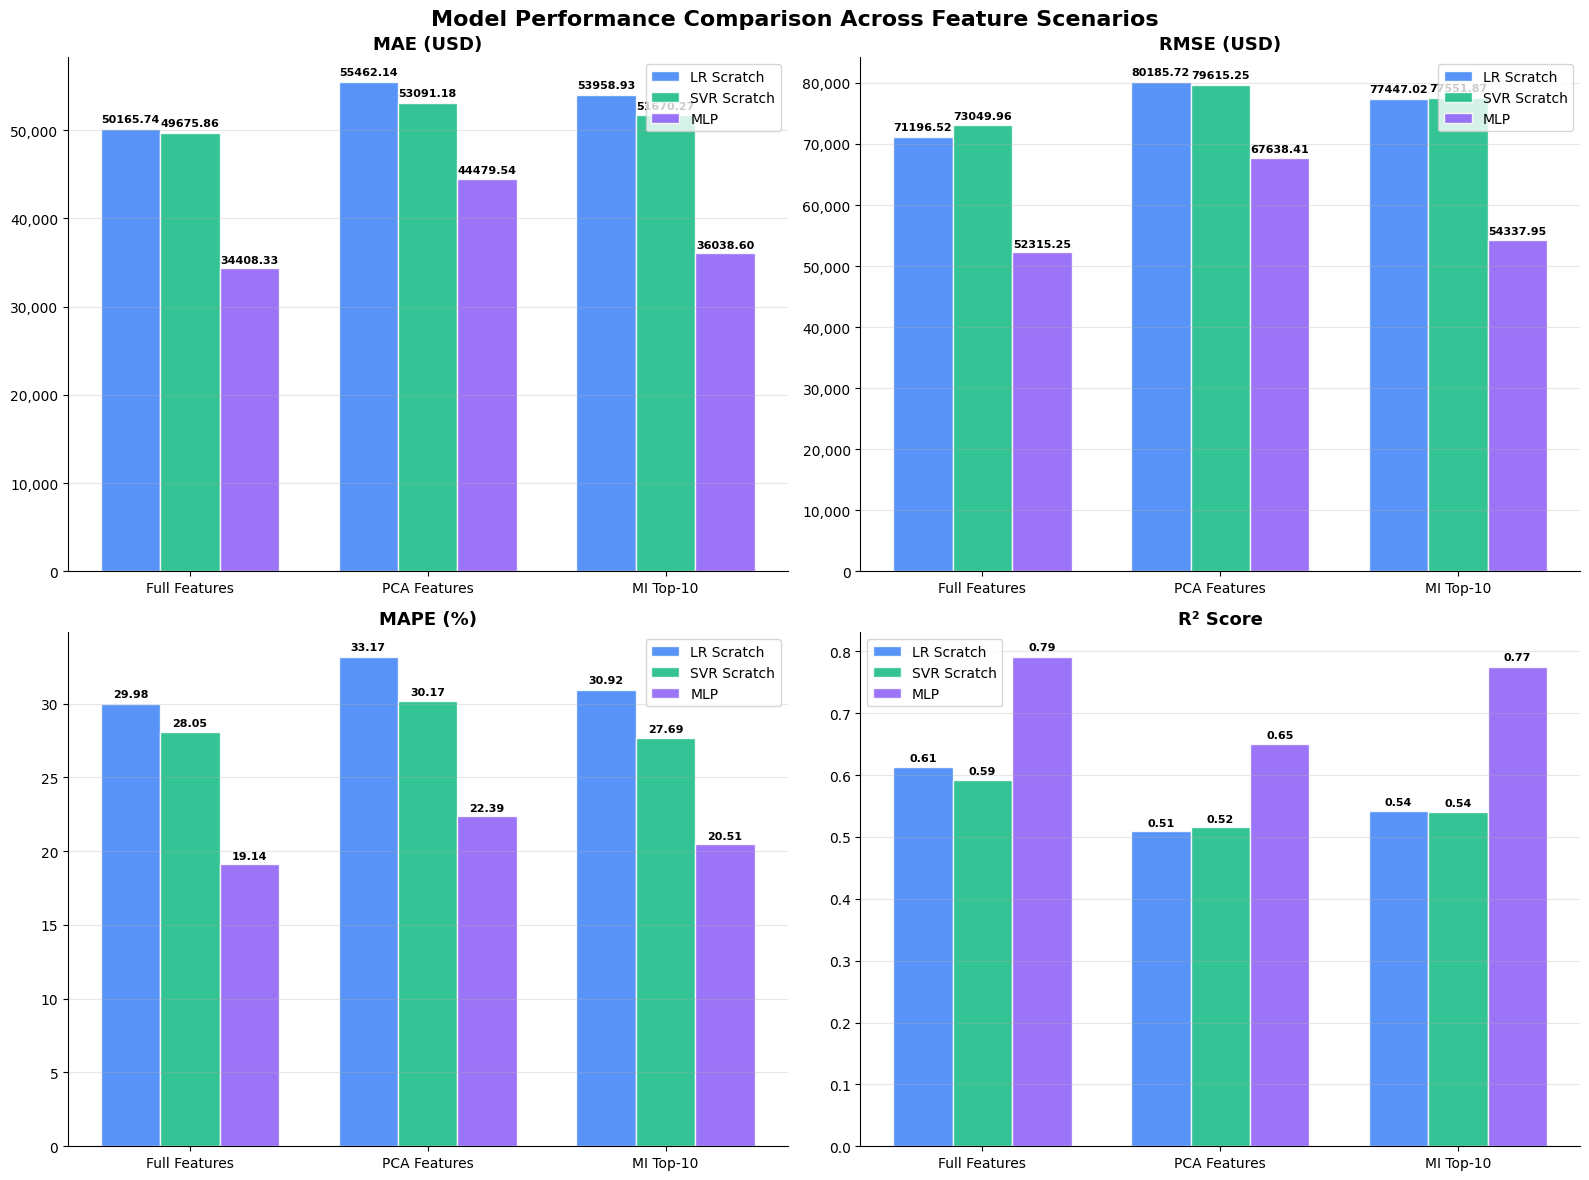

In [11]:
metrics_cols = ['MAE', 'RMSE', 'MAPE(%)', 'R2']
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R² Score']
model_order = ['LR Scratch', 'SVR Scratch', 'MLP']
sc_order = ['Full Features', 'PCA Features', 'MI Top-10']
bar_colors = ['#3B82F6', '#10B981', '#8B5CF6']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Performance Comparison Across Feature Scenarios', fontsize=16, fontweight='bold')

for idx, (metric, label) in enumerate(zip(metrics_cols, metric_labels)):
    ax = axes[idx // 2][idx % 2]
    x = np.arange(len(sc_order))
    width = 0.25
    for mi, (mname, color) in enumerate(zip(model_order, bar_colors)):
        vals = [df[(df['Scenario']==sc) & (df['Model']==mname)][metric].values[0]
                for sc in sc_order]
        bars = ax.bar(x + mi*width, vals, width, label=mname, color=color, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(sc_order, fontsize=10)
    ax.legend(fontsize=10)
    
    # Format y-axis to display regular numbers (avoid 1e5 / scientific notation)
    if metric in ['MAE', 'RMSE']:
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
    ax.grid(True, axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 8. Prediction Scatter Plots (All Models × All Scenarios)

Scatter of predicted vs actual house prices. A perfect model would have all points on the red diagonal.

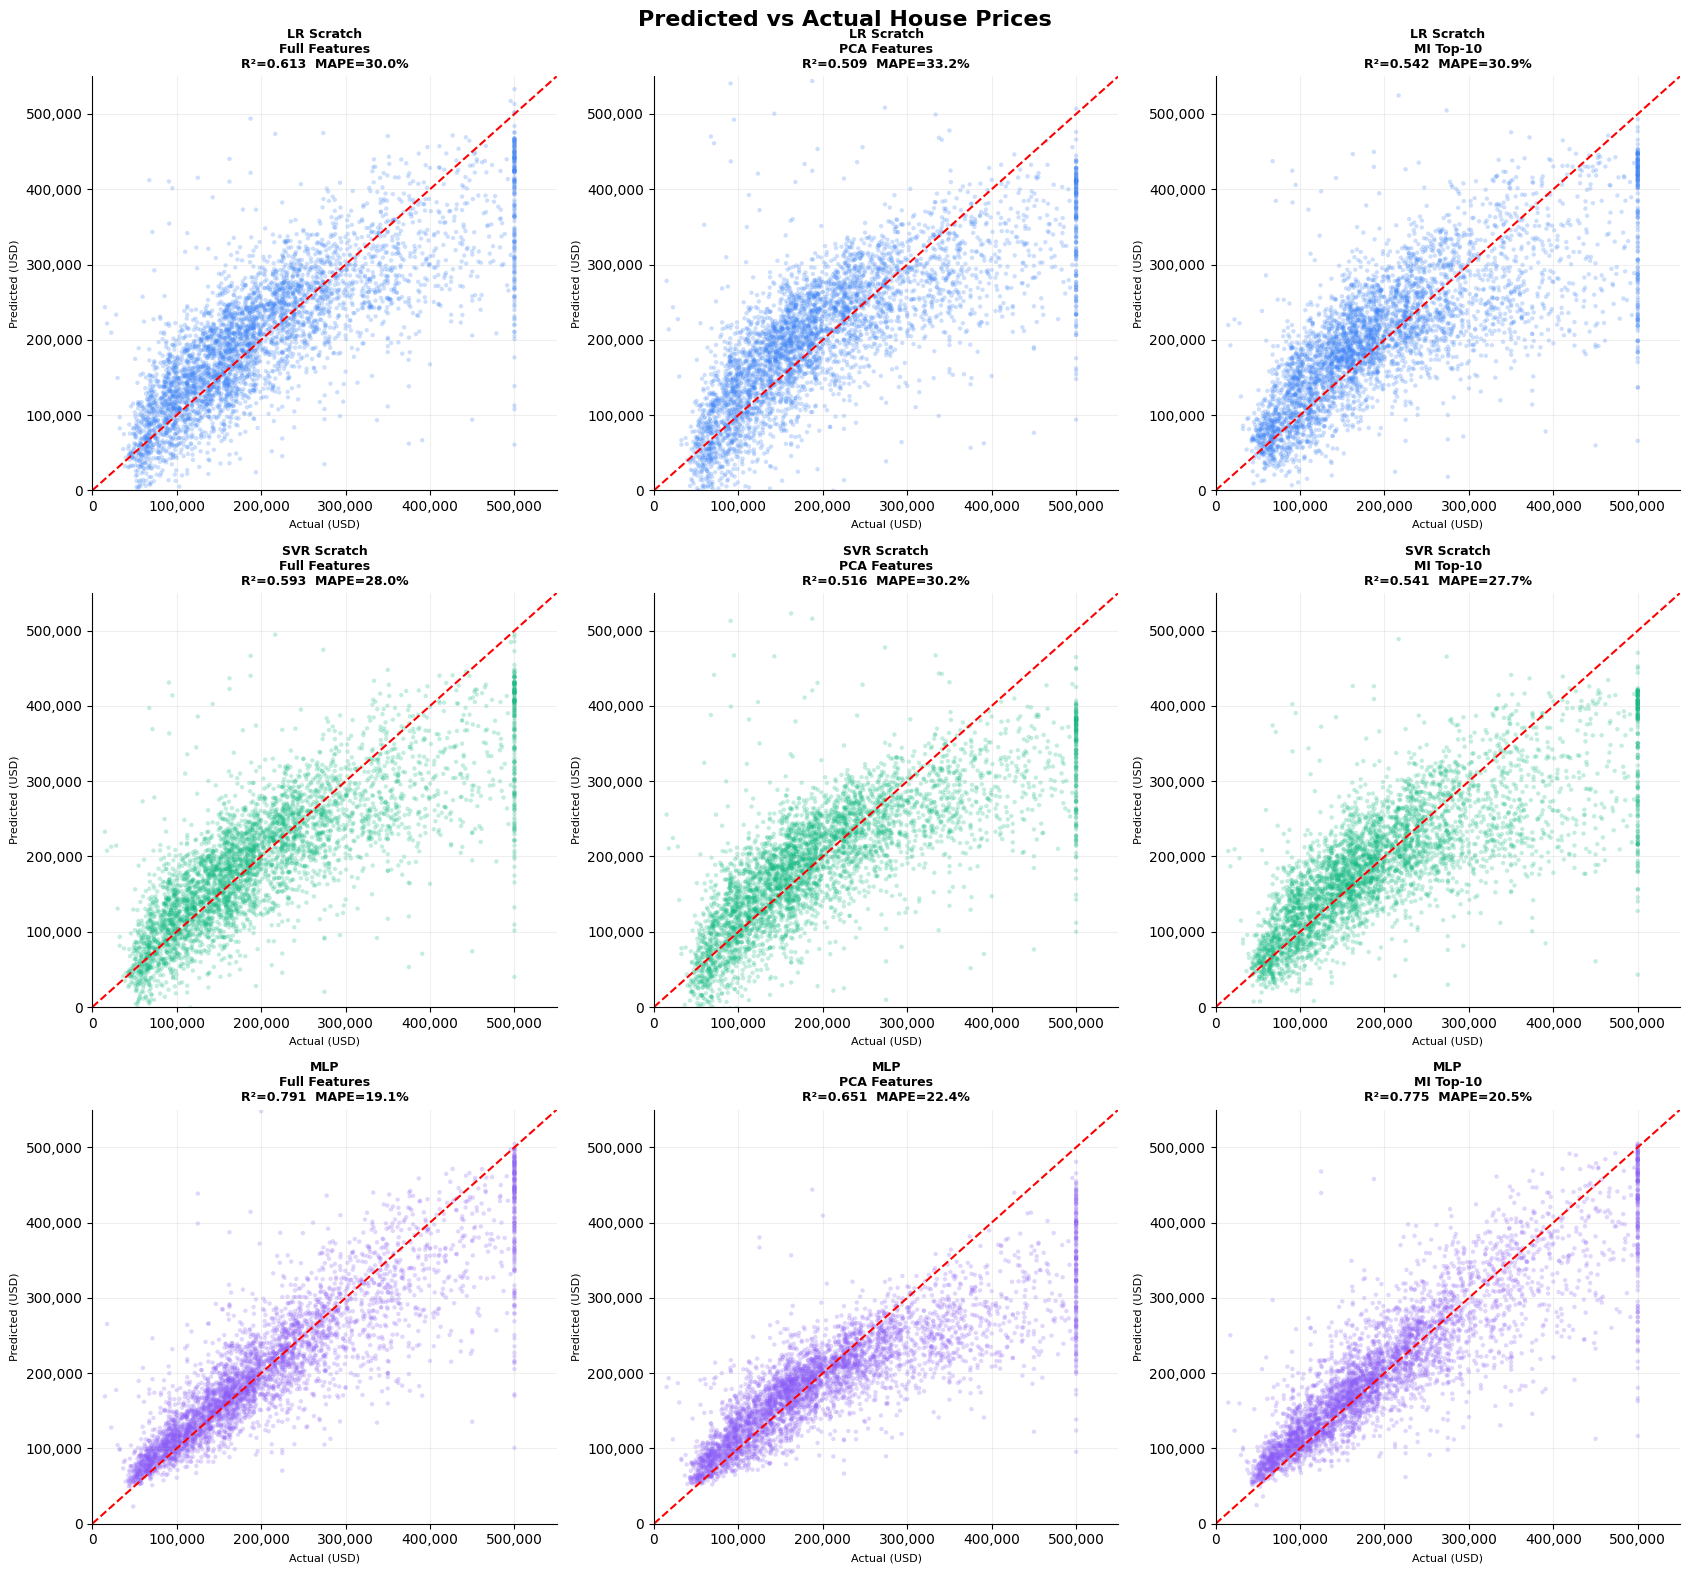

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(17, 16))
fig.suptitle('Predicted vs Actual House Prices', fontsize=16, fontweight='bold')

scatter_colors = {'LR Scratch': '#3B82F6', 'SVR Scratch': '#10B981', 'MLP': '#8B5CF6'}

for row, mname in enumerate(model_names):
    for col, sc_name in enumerate(sc_order):
        ax = axes[row][col]
        y_pred = pred_store[(sc_name, mname)]
        r2_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['R2'].values[0]
        mape_val = df[(df['Scenario']==sc_name) & (df['Model']==mname)]['MAPE(%)'].values[0]

        ax.scatter(y_test, y_pred, alpha=0.25, s=10, color=scatter_colors[mname], edgecolors='none')
        
        # Limit to the realistic housing price range to make the plots wider and focused
        ax.set_xlim([0, 550000])
        ax.set_ylim([0, 550000])
        
        # Plot diagonal line
        ax.plot([0, 550000], [0, 550000], 'r--', lw=1.5)

        # Format ticks to regular numbers with commas
        ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

        ax.set_title(f'{mname}\n{sc_name}\nR²={r2_val:.3f}  MAPE={mape_val:.1f}%',
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Actual (USD)', fontsize=8)
        ax.set_ylabel('Predicted (USD)', fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [13]:
# Tạo bản sao để định dạng hiển thị đẹp mắt
display_df = df.copy()

# Định dạng các cột số tiền mặt (USD) với dấu phẩy phân tách hàng nghìn
display_df['MAE'] = display_df['MAE'].map('{:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:,.0f}'.format)

# Định dạng các tỷ lệ phần trăm và R2 làm tròn số thập phân
display_df['MAPE(%)'] = display_df['MAPE(%)'].map('{:.2f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)

# Định dạng thời gian chạy (mili-giây)
display_df['Train_ms'] = display_df['Train_ms'].map('{:.0f}'.format)
display_df['Inf_ms'] = display_df['Inf_ms'].map('{:.1f}'.format)

# Đổi tên các cột hiển thị cho chuyên nghiệp
display_df.columns = [
    'Scenario', 
    'Model', 
    'MAE (USD)', 
    'RMSE (USD)', 
    'MAPE (%)', 
    'R² Score', 
    'Train (ms)', 
    'Inf (ms)'
]

print('\n--- Final Scenario Comparison Results Table ---')
print(display_df.to_string(index=False))


--- Final Scenario Comparison Results Table ---
     Scenario       Model MAE (USD) RMSE (USD) MAPE (%) R² Score Train (ms) Inf (ms)
Full Features  LR Scratch    50,166     71,197    29.98   0.6132        480      2.0
Full Features SVR Scratch    49,676     73,050    28.05   0.5928      15113      1.0
Full Features         MLP    34,408     52,315    19.14   0.7911     222866      2.0
 PCA Features  LR Scratch    55,462     80,186    33.17   0.5093        129      1.0
 PCA Features SVR Scratch    53,091     79,615    30.17   0.5163       2887      0.5
 PCA Features         MLP    44,480     67,638    22.39   0.6509     210405      5.0
    MI Top-10  LR Scratch    53,959     77,447    30.92   0.5423        240      0.5
    MI Top-10 SVR Scratch    51,670     77,552    27.69   0.5410       4826      1.5
    MI Top-10         MLP    36,039     54,338    20.51   0.7747     178205      6.6
